### Distance Use case

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
# lets create dummy data
data = {
    'income':[3,2.5,17,18],
    'credit_score':[450,480,750,789],
    'Status':['NO','NO','YES','YES']

}
df = pd.DataFrame(data)
df

,income,credit_score,Status
0,3.0,450,NO
1,2.5,480,NO
2,17.0,750,YES
3,18.0,789,YES


In [4]:
# lets do some experiment : how to calculate the distance between two points
# point1 = np.array([3,450])
# point2 = np.array([3,450])

# distance = np.sqrt((point1[0]-point2[0])**2 + (point1[1]-point2[1])**2)
# distance

# lets wrap it in a function
def euclidean_distance(df, pts_arr):
    point1 = np.array([df['income'], df['credit_score']])
    point2 = np.array(pts_arr)
    distance = np.sqrt((point1[0]-point2[0])**2 + (point1[1]-point2[1])**2)
    return distance



In [5]:
# new customer data point
new_customer = [4.5,510]
df['distance'] = df.apply(lambda row: euclidean_distance(row, new_customer), axis=1)
df.sort_values(by='distance')
# from the sorted values we can see that the nearest neighbours are both 'NO' status
# hence we can classify this new customer as 'NO' status

,income,credit_score,Status,distance
1,2.5,480,NO,30.066593
0,3.0,450,NO,60.018747
2,17.0,750,YES,240.325300
3,18.0,789,YES,279.326422


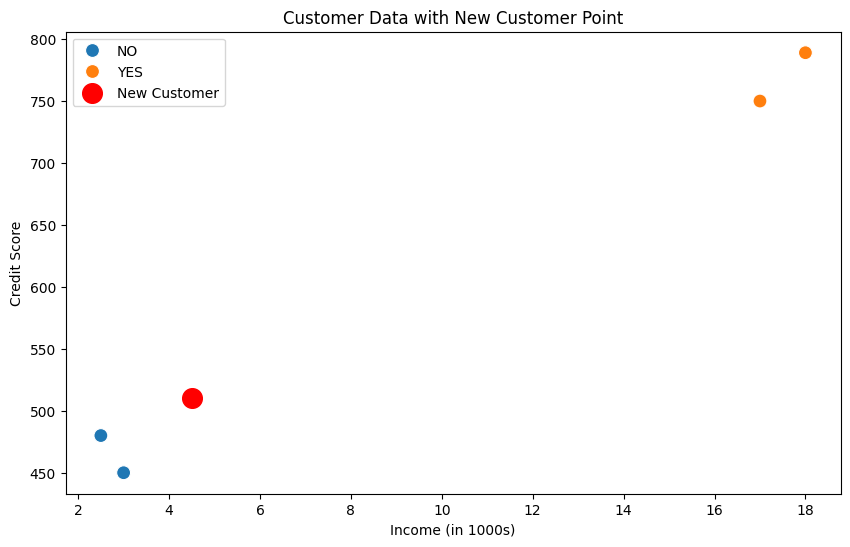

In [6]:
# you can also plot it with distance from all other points
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='income', y='credit_score', hue='Status', s=100)
plt.scatter(new_customer[0], new_customer[1], color='red', s=200, label='New Customer')
plt.title('Customer Data with New Customer Point')
plt.xlabel('Income (in 1000s)')
plt.ylabel('Credit Score')
plt.legend()
plt.show()

In [7]:
# cosine similarity can also be used for distance calculation in higher dimensions
np.dot(np.array([45,750]), np.array([3,450])) / (np.linalg.norm(np.array([3,450])) * np.linalg.norm(np.array([4.5,510])))

np.float64(1.471086514503545)

### 2.0 LINE

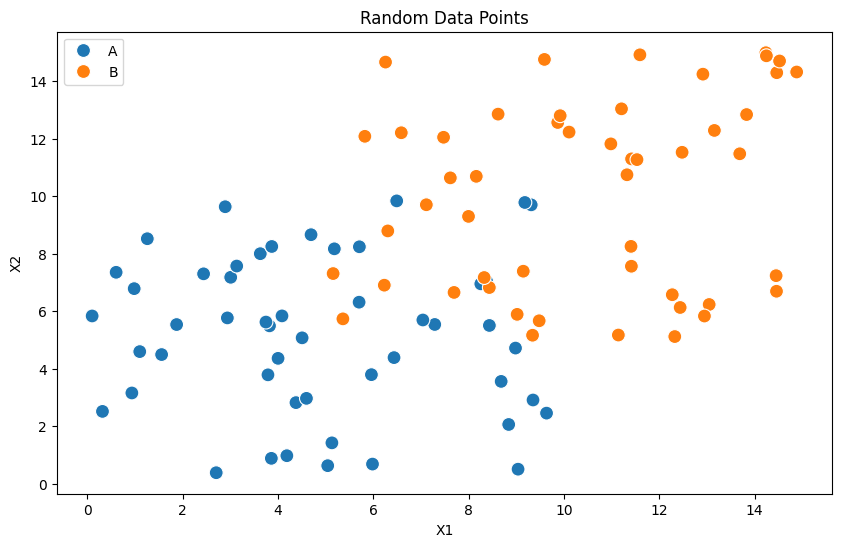

In [8]:
# lets create the random data to show how line can separate two classes ( data should be linearly separable)
data = {
    'x1': np.random.uniform(0,10,50).tolist() + np.random.uniform(5,15,50).tolist(),
    'x2': np.random.uniform(0,10,50).tolist() + np.random.uniform(5,15,50).tolist(),
    'label': ['A']*50 + ['B']*50
}

df2 = pd.DataFrame(data)
df2.head()

# plotting the random data
plt.figure(figsize=(10,6))
sns.scatterplot(data=df2, x='x1', y='x2', hue='label', s=100)
plt.title('Random Data Points')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()

In [9]:
df2.head()

,x1,x2,label
0,1.559904,4.488665,A
1,9.314021,9.699379,A
2,3.630167,7.999598,A
3,3.823189,5.487369,A
4,4.085284,5.833956,A


Text(0.5, 1.0, 'Random Data Points with Decision Boundary')

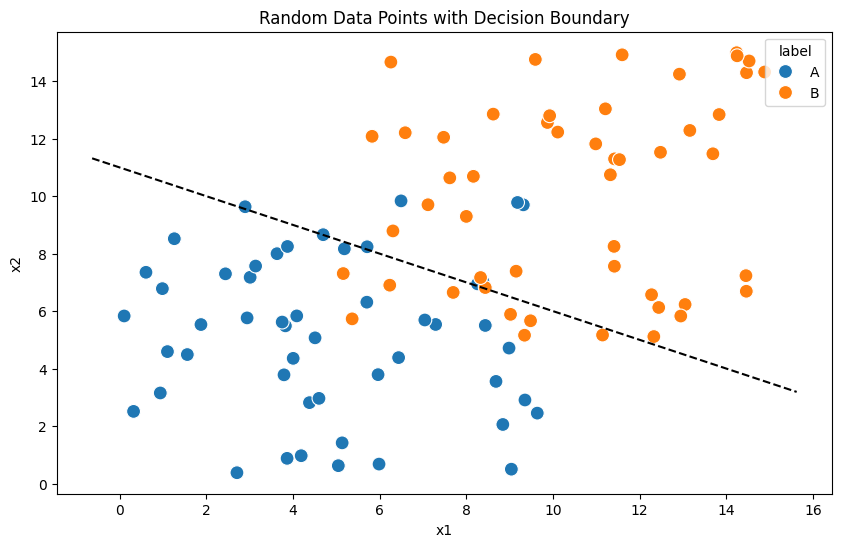

In [10]:
# lets manually draw a line to separate the two classes

w1 = 0.5
w2 = 1
w0 = -11

# plotting the random data with separating line
plt.figure(figsize=(10,6))
sns.scatterplot(data=df2, x='x1', y='x2', hue='label', s=100)
x_vals = np.array(plt.gca().get_xlim())
y_vals = -(w0 + w1 * x_vals) / w2 # y=mx + c  =>  y = -(c + mx)/m
plt.plot(x_vals, y_vals, color='black', linestyle='--', label='Decision Boundary')
plt.title('Random Data Points with Decision Boundary')

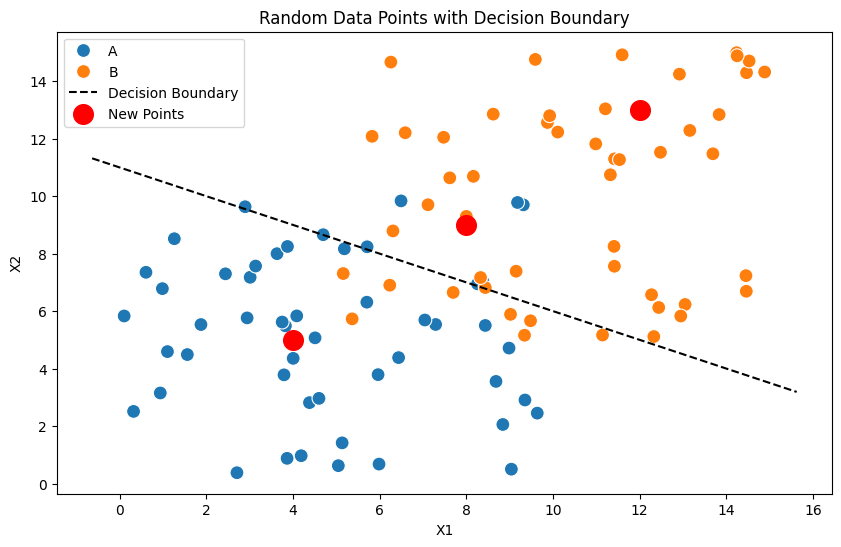

In [11]:
# new customer points to classify
# lets manually draw a line to separate the two classes

w1 = 0.5
w2 = 1
w0 = -11

# plotting the random data with separating line
plt.figure(figsize=(10,6))
sns.scatterplot(data=df2, x='x1', y='x2', hue='label', s=100)
x_vals = np.array(plt.gca().get_xlim())
y_vals = -(w0 + w1 * x_vals) / w2 # y=mx + c  =>  y = -(c + mx)/m
plt.plot(x_vals, y_vals, color='black', linestyle='--', label='Decision Boundary')
plt.title('Random Data Points with Decision Boundary')

new_points = np.array([[4,5],[8,9],[12,13]])
plt.scatter(new_points[:,0], new_points[:,1], color='red', s=200, label='New Points')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()

Point [4 5] is classified as class A
Point [8 9] is classified as class B
Point [12 13] is classified as class B


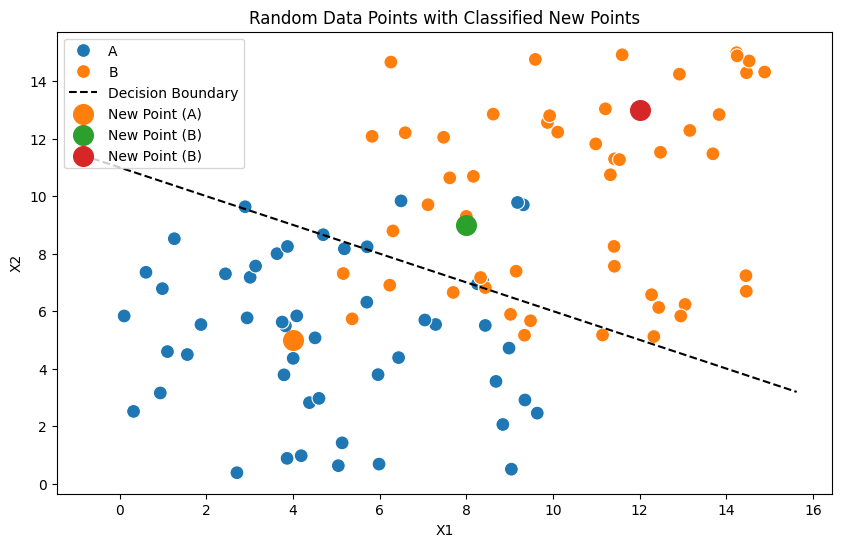

In [12]:
# classifier logic
def classify_point(point, w0, w1, w2):
    linear_combination = w0 + w1 * point[0] + w2 * point[1]
    if linear_combination >= 0:
        return 'B'
    else:
        return 'A'
    
# classify new points
for pt in new_points:
    label = classify_point(pt, w0, w1, w2)
    print(f'Point {pt} is classified as class {label}')

# plot the new points with their classified labels
plt.figure(figsize=(10,6))
sns.scatterplot(data=df2, x='x1', y='x2', hue='label', s=100)
x_vals = np.array(plt.gca().get_xlim())
y_vals = -(w0 + w1 * x_vals) / w2 # y=mx + c  =>  y = -(c + mx)/m
plt.plot(x_vals, y_vals, color='black', linestyle='--', label='Decision Boundary')
for pt in new_points:
    label = classify_point(pt, w0, w1, w2)
    plt.scatter(pt[0], pt[1], s=200, label=f'New Point ({label})')
plt.title('Random Data Points with Classified New Points')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()

In [13]:
# How Line can help in Classification
# Classifier logic is based on the concept of a decision boundary, which is represented by a line (or hyperplane in higher dimensions).
# The equation of the line is given by:
#     w0 + w1*x1 + w2*x2 = 0
# where w0 is the bias term, and w1 and w2 are the weights associated with features x1 and x2, respectively.
# The position of a point relative to this line determines its class:
# - If w0 + w1*x1 + w2*x2 >= 0, the point is classified as class 'B'.
# - If w0 + w1*x1 + w2*x2 < 0, the point is classified as class 'A'.

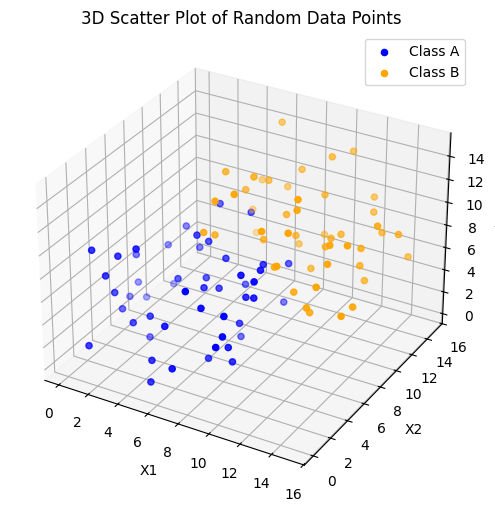

In [14]:
# same thing you can do for 3D
# In 3D, the decision boundary is represented by a plane, and the equation becomes:
#     w0 + w1*x1 + w2*x2 + w3*x3 = 0
# The classification logic remains the same, with the addition of the third feature x

data = {
    'x1': np.random.uniform(0,10,50).tolist() + np.random.uniform(5,15,50).tolist(),
    'x2': np.random.uniform(0,10,50).tolist() + np.random.uniform(5,15,50).tolist(),
    'x3': np.random.uniform(0,10,50).tolist() + np.random.uniform(5,15,50).tolist(),
    'label': ['A']*50 + ['B']*50
}
df3 = pd.DataFrame(data)

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df3[df3['label']=='A']['x1'], df3[df3['label']=='A']['x2'], df3[df3['label']=='A']['x3'], color='blue', label='Class A')
ax.scatter(df3[df3['label']=='B']['x1'], df3[df3['label']=='B']['x2'], df3[df3['label']=='B']['x3'], color='orange', label='Class B')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_title('3D Scatter Plot of Random Data Points')
ax.legend()
plt.show()


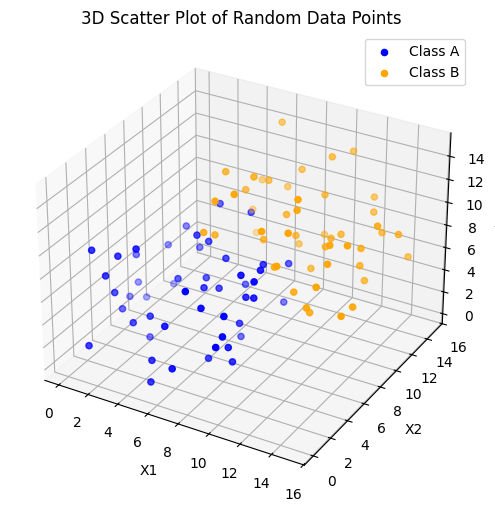

In [15]:
# lets draw plane to separate the two classes
w1 = 0.5
w2 = 1
w3 = -1
w0 = -15
# plotting the random data with separating plane
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df3[df3['label']=='A']['x1'], df3[df3['label']=='A']['x2'], df3[df3['label']=='A']['x3'], color='blue', label='Class A')
ax.scatter(df3[df3['label']=='B']['x1'], df3[df3['label']=='B']['x2'], df3[df3['label']=='B']['x3'], color='orange', label='Class B')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_title('3D Scatter Plot of Random Data Points')
ax.legend()
plt.show()


In [17]:
# you can use plotly for better 3D visualization
import plotly.graph_objects as go

# lets also add legend for the plane
fig = go.Figure()
# scatter points
fig.add_trace(go.Scatter3d(
    x=df3[df3['label']=='A']['x1'],
    y=df3[df3['label']=='A']['x2'],
    z=df3[df3['label']=='A']['x3'],
    mode='markers',
    marker=dict(size=5, color='blue'),
    name='Class A'
))
fig.add_trace(go.Scatter3d(
    x=df3[df3['label']=='B']['x1'],
    y=df3[df3['label']=='B']['x2'],
    z=df3[df3['label']=='B']['x3'],
    mode='markers',
    marker=dict(size=5, color='orange'),
    name='Class B'
))
# plane
xx, yy = np.meshgrid(range(0,16), range(0,16))
zz = ( -w0 - w1 * xx - w2 * yy ) / w3
fig.add_trace(go.Surface(x=xx, y=yy, z=zz, colorscale='Viridis', opacity=0.5, name='Decision Boundary'))
fig.update_layout(title='3D Scatter Plot with Decision Boundary', scene=dict(
                    xaxis_title='X1',
                    yaxis_title='X2',
                    zaxis_title='X3'),
                  legend=dict(x=0.7, y=0.9))
fig.show()

### Reference
- https://medium.com/@ambika199820/basic-concepts-of-linear-algebra-for-data-science-and-machine-learning-1e2ebdc56521